# Version 20 : Neural Network pour Prédiction de Survie

**Objectif** : Créer un modèle de réseau de neurones profond adapté à la survie

**Approche** :
- Architecture neural network inspirée de DeepSurv
- Loss function de Cox proportional hazards
- Feature engineering complet (clinical + molecular + cytogenetic)

## 1. Setup & Imports

In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Survival analysis
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✓ Libraries imported
PyTorch version: 2.9.1+cpu
CUDA available: False


## 2. Data Loading

In [3]:
# Load data - Using forward slashes (works on Windows too)
import os
DATA_PATH = "C:/Users/guill/Desktop/Data Challenge QRT/Data-Challenge-Prediction-de-Survie"

clinical_train = pd.read_csv(os.path.join(DATA_PATH, "X_train", "clinical_train.csv"))
target_train = pd.read_csv(os.path.join(DATA_PATH, "target_train.csv"))
clinical_test = pd.read_csv(os.path.join(DATA_PATH, "X_test", "clinical_test.csv"))
molecular_train = pd.read_csv(os.path.join(DATA_PATH, "X_train", "molecular_train.csv"))
molecular_test = pd.read_csv(os.path.join(DATA_PATH, "X_test", "molecular_test.csv"))

print(f"✓ Data loaded: {clinical_train.shape[0]} train patients")
print(f"  Test patients: {clinical_test.shape[0]}")
print(f"\nClinical features: {clinical_train.columns.tolist()}")

✓ Data loaded: 3323 train patients
  Test patients: 1193

Clinical features: ['ID', 'CENTER', 'BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT', 'CYTOGENETICS']


## 3. Feature Engineering Functions

In [4]:
def create_cytogenetic_features(clinical_df):
    """Create cytogenetic features from CYTOGENETICS column"""
    cyto_features = pd.DataFrame(index=clinical_df['ID'])
    cyto_col = clinical_df.set_index('ID')['CYTOGENETICS'].fillna('')
    
    # Anomaly types
    cyto_features['cyto_del_count'] = cyto_col.str.count(r'del\(')
    cyto_features['cyto_has_del'] = (cyto_features['cyto_del_count'] > 0).astype(int)
    cyto_features['cyto_transloc_count'] = cyto_col.str.count(r't\(')
    cyto_features['cyto_has_transloc'] = (cyto_features['cyto_transloc_count'] > 0).astype(int)
    cyto_features['cyto_inv_count'] = cyto_col.str.count(r'inv\(')
    cyto_features['cyto_has_inv'] = (cyto_features['cyto_inv_count'] > 0).astype(int)
    cyto_features['cyto_gain_count'] = cyto_col.str.count(r'\+')
    cyto_features['cyto_has_gain'] = (cyto_features['cyto_gain_count'] > 0).astype(int)
    cyto_features['cyto_loss_count'] = cyto_col.str.count(r'-[0-9XY]')
    cyto_features['cyto_has_loss'] = (cyto_features['cyto_loss_count'] > 0).astype(int)
    
    # Complexity
    cyto_features['cyto_total_anomalies'] = (
        cyto_features['cyto_del_count'] + cyto_features['cyto_transloc_count'] + 
        cyto_features['cyto_inv_count'] + cyto_features['cyto_gain_count'] + 
        cyto_features['cyto_loss_count']
    )
    cyto_features['cyto_normal'] = cyto_col.str.match(r'^46,(xx|xy)(\[\d+\])?$', case=False).astype(int)
    cyto_features['cyto_complex'] = (
        (cyto_features['cyto_total_anomalies'] >= 3) | 
        cyto_col.str.contains('complex', case=False, na=False)
    ).astype(int)
    
    # Prognostic markers
    cyto_features['cyto_monosomy7'] = cyto_col.str.contains(r'-7[^0-9]|^45.*-7', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_trisomy8'] = cyto_col.str.contains(r'\+8[^0-9]|^47.*\+8', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_del5q'] = cyto_col.str.contains(r'del\(5\)\(q', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_del20q'] = cyto_col.str.contains(r'del\(20\)\(q', case=False, na=False, regex=True).astype(int)
    
    return cyto_features.fillna(0)

def create_molecular_features(molecular_df, patient_ids, top_n_genes=20):
    """Create molecular features"""
    mol_features = pd.DataFrame({'ID': patient_ids})
    
    # Mutation counts
    mutation_counts = molecular_df.groupby('ID').size().to_frame('mutation_count_total')
    mol_features = mol_features.merge(mutation_counts, on='ID', how='left')
    
    # VAF stats
    vaf_stats = molecular_df.groupby('ID')['VAF'].agg([
        ('vaf_mean', 'mean'), ('vaf_max', 'max'), ('vaf_sum', 'sum')
    ]).reset_index()
    mol_features = mol_features.merge(vaf_stats, on='ID', how='left')
    
    # Effect types
    effect_counts = molecular_df.groupby(['ID', 'EFFECT']).size().unstack(fill_value=0)
    effect_counts.columns = [f'effect_{col}' for col in effect_counts.columns]
    mol_features = mol_features.merge(effect_counts.reset_index(), on='ID', how='left')
    
    # Top genes
    top_genes_list = molecular_df['GENE'].value_counts().head(top_n_genes).index.tolist()
    for gene in top_genes_list:
        gene_mutations = molecular_df[molecular_df['GENE'] == gene].groupby('ID').size()
        mol_features[f'gene_{gene}_count'] = mol_features['ID'].map(gene_mutations)
        gene_present = molecular_df[molecular_df['GENE'] == gene]['ID'].unique()
        mol_features[f'gene_{gene}_present'] = mol_features['ID'].isin(gene_present).astype(int)
    
    feature_cols = [col for col in mol_features.columns if col != 'ID']
    mol_features[feature_cols] = mol_features[feature_cols].fillna(0)
    return mol_features.set_index('ID')

print("✓ Feature engineering functions defined")

✓ Feature engineering functions defined


## 4. Feature Engineering

In [5]:
# Clean target
target_clean = target_train.dropna(subset=['OS_YEARS', 'OS_STATUS']).copy()
target_clean['OS_STATUS'] = target_clean['OS_STATUS'].astype(bool)
target_clean = target_clean.set_index('ID')

# Clinical features - TRAIN
clinical_train_clean = clinical_train[clinical_train['ID'].isin(target_clean.index)].copy()
clinical_train_clean = clinical_train_clean.set_index('ID').loc[target_clean.index]

numeric_features = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
X_clinical_train = clinical_train_clean[numeric_features].copy()
center_encoded_train = pd.get_dummies(clinical_train_clean['CENTER'], prefix='CENTER', drop_first=True)
X_clinical_train = pd.concat([X_clinical_train, center_encoded_train], axis=1)

# Clinical features - TEST
X_clinical_test = clinical_test.set_index('ID')[numeric_features].copy()
center_encoded_test = pd.get_dummies(clinical_test.set_index('ID')['CENTER'], prefix='CENTER', drop_first=True)
X_clinical_test = pd.concat([X_clinical_test, center_encoded_test], axis=1)

# Ensure same columns in test
for col in X_clinical_train.columns:
    if col not in X_clinical_test.columns:
        X_clinical_test[col] = 0
X_clinical_test = X_clinical_test[X_clinical_train.columns]

# Cytogenetic features
cyto_features_train = create_cytogenetic_features(clinical_train)
cyto_features_test = create_cytogenetic_features(clinical_test)

# Molecular features
train_patient_ids = clinical_train_clean.index.unique()
test_patient_ids = clinical_test['ID'].unique()
mol_features_train = create_molecular_features(molecular_train, train_patient_ids, top_n_genes=20)
mol_features_test = create_molecular_features(molecular_test, test_patient_ids, top_n_genes=20)

# Ensure same columns in test molecular features
for col in mol_features_train.columns:
    if col not in mol_features_test.columns:
        mol_features_test[col] = 0
mol_features_test = mol_features_test[mol_features_train.columns]

# Combine all features - TRAIN
mol_features_train_aligned = mol_features_train.reindex(X_clinical_train.index, fill_value=0)
cyto_features_train_aligned = cyto_features_train.reindex(X_clinical_train.index, fill_value=0)
X_combined_train = pd.concat([X_clinical_train, mol_features_train_aligned, cyto_features_train_aligned], axis=1)

# Combine all features - TEST
mol_features_test_aligned = mol_features_test.reindex(X_clinical_test.index, fill_value=0)
cyto_features_test_aligned = cyto_features_test.reindex(X_clinical_test.index, fill_value=0)
X_combined_test = pd.concat([X_clinical_test, mol_features_test_aligned, cyto_features_test_aligned], axis=1)

print(f"✓ Combined features shape (train): {X_combined_train.shape}")
print(f"✓ Combined features shape (test): {X_combined_test.shape}")
print(f"  - Clinical: {X_clinical_train.shape[1]}")
print(f"  - Molecular: {mol_features_train_aligned.shape[1]}")
print(f"  - Cytogenetic: {cyto_features_train_aligned.shape[1]}")

✓ Combined features shape (train): (3173, 105)
✓ Combined features shape (test): (1193, 105)
  - Clinical: 28
  - Molecular: 60
  - Cytogenetic: 17


## 5. Data Preprocessing & Normalization

In [6]:
# Imputation
imputer = SimpleImputer(strategy='median')
X_imputed_train = pd.DataFrame(
    imputer.fit_transform(X_combined_train),
    index=X_combined_train.index,
    columns=X_combined_train.columns
)

X_imputed_test = pd.DataFrame(
    imputer.transform(X_combined_test),
    index=X_combined_test.index,
    columns=X_combined_test.columns
)

# Standardization (important for neural networks)
scaler = StandardScaler()
X_scaled_train = pd.DataFrame(
    scaler.fit_transform(X_imputed_train),
    index=X_imputed_train.index,
    columns=X_imputed_train.columns
)

X_scaled_test = pd.DataFrame(
    scaler.transform(X_imputed_test),
    index=X_imputed_test.index,
    columns=X_imputed_test.columns
)

# Create survival target
y_surv = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_clean)

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled_train, y_surv, test_size=0.2, random_state=42,
    stratify=target_clean['OS_STATUS'].astype(int)
)

print(f"✓ Preprocessed data:")
print(f"  Train: {X_train.shape[0]} patients, {X_train.shape[1]} features")
print(f"  Val: {X_val.shape[0]} patients")
print(f"  Test: {X_scaled_test.shape[0]} patients")
print(f"  Target events: {y_surv['OS_STATUS'].sum()} / {len(y_surv)}")

✓ Preprocessed data:
  Train: 2538 patients, 105 features
  Val: 635 patients
  Test: 1193 patients
  Target events: 1600 / 3173


## 6. PyTorch Dataset & DataLoader

In [8]:
class SurvivalDataset(Dataset):
    """Custom Dataset for survival data"""
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X.values)
        self.event = torch.FloatTensor(y['OS_STATUS'].astype(float))
        # Fix: Add .copy() to ensure contiguous memory
        self.time = torch.FloatTensor(np.array(y['OS_YEARS'], dtype=np.float32))
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.event[idx], self.time[idx]

# Create datasets
train_dataset = SurvivalDataset(X_train, y_train)
val_dataset = SurvivalDataset(X_val, y_val)

# Create dataloaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"✓ DataLoaders created")
print(f"  Batch size: {batch_size}")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

✓ DataLoaders created
  Batch size: 64
  Train batches: 40
  Val batches: 10


## 7. Neural Network Model (DeepSurv-inspired)

In [9]:
class DeepSurvModel(nn.Module):
    """Deep neural network for survival analysis"""
    def __init__(self, input_dim, hidden_layers=[128, 64, 32], dropout=0.3):
        super(DeepSurvModel, self).__init__()
        
        self.layers = nn.ModuleList()
        
        # Input layer
        self.layers.append(nn.Linear(input_dim, hidden_layers[0]))
        self.layers.append(nn.BatchNorm1d(hidden_layers[0]))
        self.layers.append(nn.ReLU())
        self.layers.append(nn.Dropout(dropout))
        
        # Hidden layers
        for i in range(len(hidden_layers)-1):
            self.layers.append(nn.Linear(hidden_layers[i], hidden_layers[i+1]))
            self.layers.append(nn.BatchNorm1d(hidden_layers[i+1]))
            self.layers.append(nn.ReLU())
            self.layers.append(nn.Dropout(dropout))
        
        # Output layer (single value for risk score)
        self.output = nn.Linear(hidden_layers[-1], 1)
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return self.output(x)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_dim = X_train.shape[1]
model = DeepSurvModel(input_dim=input_dim, hidden_layers=[128, 64, 32], dropout=0.3)
model = model.to(device)

print(f"✓ Model created")
print(f"  Device: {device}")
print(f"  Input dimension: {input_dim}")
print(f"\nModel architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

✓ Model created
  Device: cpu
  Input dimension: 105

Model architecture:
DeepSurvModel(
  (layers): ModuleList(
    (0): Linear(in_features=105, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
  )
  (output): Linear(in_features=32, out_features=1, bias=True)
)

Total parameters: 24,385
Trainable parameters: 24,385


## 8. Cox Proportional Hazards Loss Function

In [10]:
def cox_ph_loss(risk_scores, events, times):
    """
    Cox proportional hazards loss (negative partial log-likelihood)
    
    Args:
        risk_scores: Model predictions (batch_size, 1)
        events: Event indicators (batch_size,)
        times: Survival times (batch_size,)
    """
    # Sort by survival time (descending)
    sorted_indices = torch.argsort(times, descending=True)
    risk_scores = risk_scores[sorted_indices].squeeze()
    events = events[sorted_indices]
    
    # Compute hazard ratios
    hazard_ratio = torch.exp(risk_scores)
    
    # Compute cumulative sum (risk set)
    log_risk = torch.log(torch.cumsum(hazard_ratio, dim=0) + 1e-7)
    
    # Compute uncensored likelihood
    uncensored_likelihood = risk_scores - log_risk
    
    # Only consider events (not censored)
    loss = -torch.sum(uncensored_likelihood * events) / (torch.sum(events) + 1e-7)
    
    return loss

print("✓ Cox PH loss function defined")

✓ Cox PH loss function defined


## 9. Training Functions

In [11]:
def train_epoch(model, dataloader, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    
    for X_batch, event_batch, time_batch in dataloader:
        X_batch = X_batch.to(device)
        event_batch = event_batch.to(device)
        time_batch = time_batch.to(device)
        
        optimizer.zero_grad()
        
        risk_scores = model(X_batch)
        loss = cox_ph_loss(risk_scores, event_batch, time_batch)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

def evaluate(model, dataloader, device):
    """Evaluate model"""
    model.eval()
    total_loss = 0
    all_risk_scores = []
    all_events = []
    all_times = []
    
    with torch.no_grad():
        for X_batch, event_batch, time_batch in dataloader:
            X_batch = X_batch.to(device)
            event_batch = event_batch.to(device)
            time_batch = time_batch.to(device)
            
            risk_scores = model(X_batch)
            loss = cox_ph_loss(risk_scores, event_batch, time_batch)
            
            total_loss += loss.item()
            all_risk_scores.extend(risk_scores.cpu().numpy())
            all_events.extend(event_batch.cpu().numpy())
            all_times.extend(time_batch.cpu().numpy())
    
    # Compute C-index
    all_risk_scores = np.array(all_risk_scores).flatten()
    all_events = np.array(all_events).astype(bool)
    all_times = np.array(all_times)
    
    c_index = concordance_index_censored(all_events, all_times, all_risk_scores)[0]
    
    return total_loss / len(dataloader), c_index

print("✓ Training functions defined")

✓ Training functions defined


## 10. Training Loop

In [13]:
# Training configuration
learning_rate = 0.001
weight_decay = 1e-4
num_epochs = 100
patience = 15

optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
# Fix: Remove verbose=True (not supported in recent PyTorch versions)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

print("="*60)
print("TRAINING NEURAL NETWORK")
print("="*60)
print(f"Learning rate: {learning_rate}")
print(f"Weight decay: {weight_decay}")
print(f"Max epochs: {num_epochs}")
print(f"Early stopping patience: {patience}\n")

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_c_index': []
}

best_val_c_index = 0
best_model_state = None
patience_counter = 0

for epoch in range(num_epochs):
    # Train
    train_loss = train_epoch(model, train_loader, optimizer, device)
    
    # Validate
    val_loss, val_c_index = evaluate(model, val_loader, device)
    
    # Update learning rate
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_c_index'].append(val_c_index)
    
    # Print progress
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val C-index: {val_c_index:.4f}")
    
    # Early stopping
    if val_c_index > best_val_c_index:
        best_val_c_index = val_c_index
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter >= patience:
        print(f"\n✓ Early stopping at epoch {epoch+1}")
        break

# Load best model
model.load_state_dict(best_model_state)

print(f"\n✓ Training completed")
print(f"Best validation C-index: {best_val_c_index:.4f}")

TRAINING NEURAL NETWORK
Learning rate: 0.001
Weight decay: 0.0001
Max epochs: 100
Early stopping patience: 15

Epoch   5/100 | Train Loss: 3.0539 | Val Loss: 3.0439 | Val C-index: 0.7339
Epoch  10/100 | Train Loss: 2.9845 | Val Loss: 3.0504 | Val C-index: 0.7337
Epoch  15/100 | Train Loss: 2.9301 | Val Loss: 3.0774 | Val C-index: 0.7322
Epoch  20/100 | Train Loss: 2.8804 | Val Loss: 3.0601 | Val C-index: 0.7364
Epoch  25/100 | Train Loss: 2.8236 | Val Loss: 3.0665 | Val C-index: 0.7342

✓ Early stopping at epoch 26

✓ Training completed
Best validation C-index: 0.7370


## 11. Training Visualization

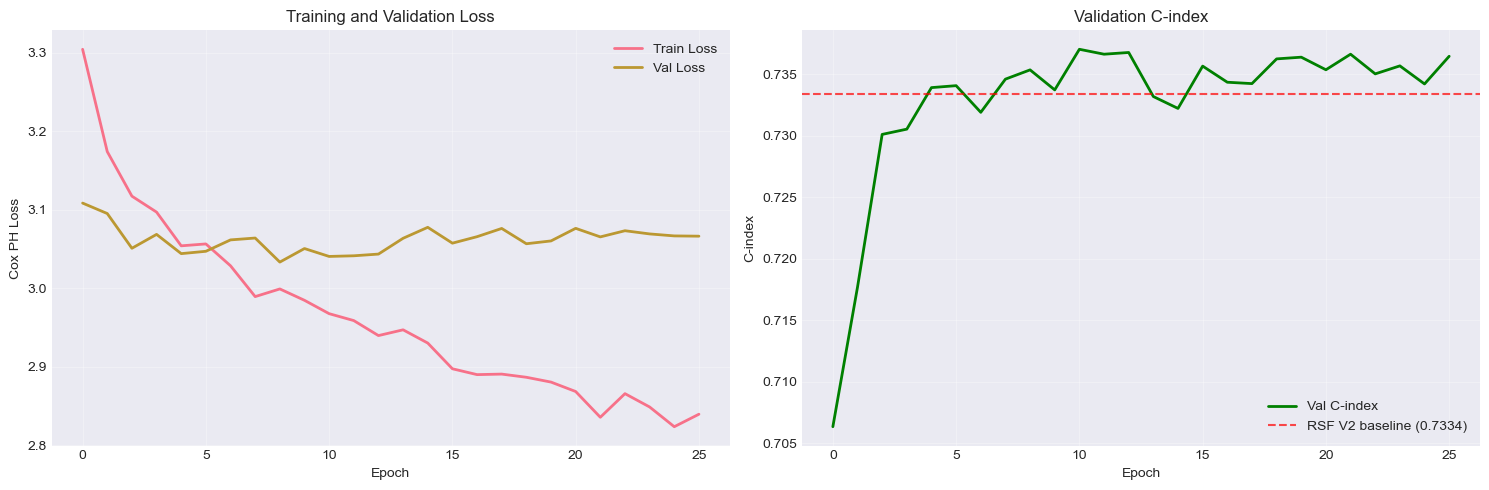

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cox PH Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# C-index curve
ax2.plot(history['val_c_index'], label='Val C-index', linewidth=2, color='green')
ax2.axhline(y=0.7334, color='r', linestyle='--', label='RSF V2 baseline (0.7334)', alpha=0.7)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('C-index')
ax2.set_title('Validation C-index')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Final Evaluation

In [15]:
# Evaluate on validation set
val_loss_final, val_c_index_final = evaluate(model, val_loader, device)

print("="*60)
print("FINAL RESULTS")
print("="*60)
print(f"Validation C-index: {val_c_index_final:.4f}")
print(f"Validation Loss: {val_loss_final:.4f}")
print(f"\nComparison:")
print(f"  RSF V2 baseline: 0.7334")
print(f"  RSF V3 baseline: 0.7320")
print(f"  Neural Network:  {val_c_index_final:.4f}")

FINAL RESULTS
Validation C-index: 0.7365
Validation Loss: 3.0662

Comparison:
  RSF V2 baseline: 0.7334
  RSF V3 baseline: 0.7320
  Neural Network:  0.7365


## 13. Predictions on Test Set

In [ ]:
# Prepare test data
X_test_tensor = torch.FloatTensor(X_scaled_test.values).to(device)

# Generate predictions
model.eval()
with torch.no_grad():
    test_risk_scores = model(X_test_tensor).cpu().numpy().flatten()

# Create submission
submission = pd.DataFrame({
    'ID': X_scaled_test.index,
    'OS_YEARS': test_risk_scores
})

# Save submission
submission_path = os.path.join(DATA_PATH, "submission_v20_neural_network.csv")
submission.to_csv(submission_path, index=False)

print(f"✓ Submission saved: {submission_path}")
print(f"\nSubmission preview:")
print(submission.head(10))
print(f"\nRisk score statistics:")
print(submission['OS_YEARS'].describe())

## 14. Summary & Next Steps

In [ ]:
print("="*60)
print("SUMMARY - Neural Network V20")
print("="*60)
print(f"\nModel Architecture:")
print(f"  - Input features: {input_dim}")
print(f"  - Hidden layers: [128, 64, 32]")
print(f"  - Dropout: 0.3")
print(f"  - Total parameters: {total_params:,}")
print(f"\nPerformance:")
print(f"  - Best Val C-index: {best_val_c_index:.4f}")
print(f"\nSubmission:")
print(f"  - File: submission_v20_neural_network.csv")
print(f"  - Test predictions: {len(submission)}")
print(f"\nPossible improvements:")
print(f"  - Try different architectures (deeper/wider networks)")
print(f"  - Experiment with learning rate schedules")
print(f"  - Add residual connections")
print(f"  - Ensemble with other models (RSF, XGBoost, CoxPH)")
print(f"  - Feature selection based on importance")
print("="*60)